[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daniellopezcano/I-Escola-de-Inverno-do-IFUSP/blob/main/jax-examples/notebooks/01_domain_shift_toy.ipynb)

# Notebook 01 — Domain Shift: Quebrar e Consertar um Classificador
### Treinar, avaliar, quebrar girando o domínio, consertar com transfer learning
**I Escola de Inverno do IFUSP — Bloco L2B2**

> **Modo de uso:** demo guiada pelo instrutor; vocês recebem o notebook depois.
> Ao final, teremos vivenciado o ciclo completo do domain shift num universo 2D
> de brinquedo — o *benchmark* das **luas entrelaçadas** (*inter-twinning moons*),
> clássico da literatura de adaptação de domínio:
>
> 1. treinar um classificador não-linear e avaliá-lo com ferramentas ricas;
> 2. **girar o domínio** por um ângulo e medir a degradação de forma controlada;
> 3. mostrar que **fine-tuning compra eficiência de rótulos**: aproveitar um modelo
>    pré-treinado bate treinar do zero, sobretudo quando temos **poucos rótulos**.

In [1]:
# Instalação de pacotes (só no Colab — localmente já estão instalados)
import subprocess, sys
try:
    import google.colab  # noqa: F401
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q",
         "jax", "jaxlib", "equinox", "optax", "matplotlib", "scikit-learn"])
except ImportError:
    pass

In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Semente de reprodutibilidade
SEED = 42
KEY = jax.random.PRNGKey(SEED)

# Estilo dos gráficos
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})

# --- Convenções visuais COMUNS a todo o notebook (R6) ---
# Cores por classe e limites de eixo fixos: todos os painéis ficam comparáveis a olho.
CORES_CLASSES = ["#e74c3c", "#3498db", "#2ecc71"]  # C0 vermelho, C1 azul, C2 verde
XLIM = (-7.0, 7.0)
YLIM = (-7.0, 7.0)
DEG = float(np.pi / 180.0)  # grau -> radiano

print(f"JAX versão  : {jax.__version__}")
print(f"Dispositivo : {jax.devices()[0]}")

JAX versão  : 0.10.2
Dispositivo : cpu:0


---
## Bloco 1 — Gerador de dados: as três luas entrelaçadas (domínio fonte)

Adotamos o *benchmark* canônico de adaptação de domínio: as **luas
entrelaçadas** (Courty et al. 2016; Germain et al., PAC-Bayes DA). Aqui em uma
versão de **três arcos** (crescentes) em vez de dois:

| Classe | Fração | Geometria |
|--------|--------|-----------|
| 0 (majoritária)   | 50 % | um arco crescente |
| 1 (intermediária) | 30 % | um segundo arco, defasado em 120° |
| 2 (minoritária)   | 20 % | um terceiro arco, defasado em 240°, mais **difuso** e o mais **entrelaçado** com os outros |

Três virtudes que fazem deste o brinquedo certo:

1. **fortemente não-linear** — arcos curvos e entrelaçados, fronteira ótima curva;
2. sobreposição real (jitter Gaussiano) ⇒ **erro de Bayes não-nulo**;
3. **um único parâmetro interpretável de shift** — o **ângulo de rotação** $\theta$.
   O domínio *alvo* será o *mesmo* conjunto girado por $\theta$ em torno da origem.

In [3]:
# --- UM gerador limpo: cada classe é um ARCO parametrizado (R1) ---

def _amostrar_arco(key, n, p):
    """Amostra n pontos de um arco crescente com espessura e ruído.

    Parâmetros em `p`: cx, cy (centro), r (raio), phi0 (ângulo inicial, rad),
    span (extensão angular, rad), esp (espessura radial), ruido (jitter Gaussiano).
    """
    ku, ke, kr = jax.random.split(key, 3)
    ang = p["phi0"] + jax.random.uniform(ku, (n,)) * p["span"]        # anda pelo arco
    rad = p["r"] + p["esp"] * jax.random.uniform(ke, (n,), minval=-1.0, maxval=1.0)
    centro = jnp.array([p["cx"], p["cy"]])
    xy = centro + jnp.stack([rad * jnp.cos(ang), rad * jnp.sin(ang)], axis=1)
    xy = xy + jax.random.normal(kr, (n, 2)) * p["ruido"]
    return xy


def gerar_dominio(config, n_total, key, theta_graus=0.0):
    """Gera um domínio 2D e o gira por `theta_graus` em torno da origem.

    Cada item de `config` é um dict {nome, cor, fracao, params}. A MESMA função
    gera a fonte (theta=0) e o alvo (theta>0) — muda-se só o ângulo (e, no Bloco 4,
    pequenas perturbações por classe). Retorna X (n, 2) e y (n,) como arrays JAX.
    """
    theta = theta_graus * DEG
    c, s = np.cos(theta), np.sin(theta)
    R = jnp.array([[c, -s], [s, c]], dtype=jnp.float32)  # rotação rígida
    X_list, y_list = [], []
    for k_cls, spec in enumerate(config):
        n_c = int(round(n_total * spec["fracao"]))
        key, sub = jax.random.split(key)
        xy = _amostrar_arco(sub, n_c, spec["params"])
        X_list.append(xy)
        y_list.append(jnp.full((n_c,), k_cls, dtype=jnp.int32))
    X = jnp.concatenate(X_list)
    y = jnp.concatenate(y_list)
    return X @ R.T, y

In [4]:
# --- Parâmetros geradores do domínio FONTE (theta = 0) ---
# Três arcos defasados de 120°, centros levemente afastados da origem => entrelaçam.
D_CENTRO = 1.6   # afastamento do centro de cada arco em relação à origem
R_ARCO = 2.9     # raio de cada arco
SPAN = 200 * DEG # extensão angular de cada crescente


def _arco_params(k, esp, ruido):
    a = k * 120 * DEG
    return {"cx": D_CENTRO * np.cos(a), "cy": D_CENTRO * np.sin(a),
            "r": R_ARCO, "phi0": a + 90 * DEG, "span": SPAN,
            "esp": esp, "ruido": ruido}


CONFIG_FONTE = [
    {"nome": "Classe 0", "cor": CORES_CLASSES[0], "fracao": 0.50,
     "params": _arco_params(0, esp=0.34, ruido=0.30)},
    {"nome": "Classe 1", "cor": CORES_CLASSES[1], "fracao": 0.30,
     "params": _arco_params(1, esp=0.34, ruido=0.30)},
    {"nome": "Classe 2", "cor": CORES_CLASSES[2], "fracao": 0.20,
     "params": _arco_params(2, esp=0.44, ruido=0.38)},  # minoritária: mais difusa
]

N_CLASSES = len(CONFIG_FONTE)
NOMES_CLASSES = [s["nome"] for s in CONFIG_FONTE]
FRACOES_FONTE = np.array([s["fracao"] for s in CONFIG_FONTE])

In [5]:
# Gerar dados fonte: treino (~20k) + validação (~10k)
N_TREINO = 20_000
N_VAL = 10_000

key_src_tr, key_src_val, KEY = jax.random.split(KEY, 3)
X_treino, y_treino = gerar_dominio(CONFIG_FONTE, N_TREINO, key_src_tr, theta_graus=0.0)
X_val, y_val = gerar_dominio(CONFIG_FONTE, N_VAL, key_src_val, theta_graus=0.0)


def resumo_split(nome, y):
    """Imprime tamanho total e proporções realizadas por classe."""
    n = int(y.shape[0])
    print(f"{nome}: {n} pontos")
    for c in range(N_CLASSES):
        n_c = int((y == c).sum())
        print(f"  {NOMES_CLASSES[c]}: {n_c:6d}  ({n_c / n:5.1%})")


resumo_split("Treino fonte", y_treino)
resumo_split("Validação fonte", y_val)

Treino fonte: 20000 pontos
  Classe 0:  10000  (50.0%)
  Classe 1:   6000  (30.0%)
  Classe 2:   4000  (20.0%)
Validação fonte: 10000 pontos


  Classe 0:   5000  (50.0%)
  Classe 1:   3000  (30.0%)
  Classe 2:   2000  (20.0%)


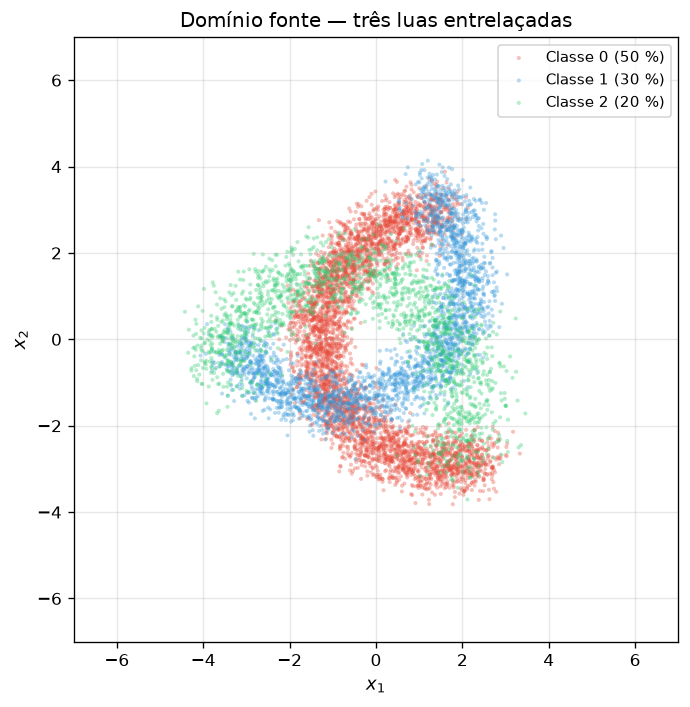

In [6]:
# --- Helper de scatter reutilizado em todo o notebook (cores e limites fixos) ---
rng_plot = np.random.default_rng(0)


def sub_amostra(X, y, n):
    """Subamostra n pontos (para figuras legíveis com dados densos)."""
    X = np.asarray(X); y = np.asarray(y)
    if len(y) <= n:
        return X, y
    idx = rng_plot.choice(len(y), n, replace=False)
    return X[idx], y[idx]


def scatter_classes(ax, X, y, titulo, s=6, alpha=0.35, fracoes=None, n_max=8000):
    """Scatter por classe, com cores e limites de eixo consistentes."""
    Xs, ys = sub_amostra(X, y, n_max)
    for c in range(N_CLASSES):
        m = ys == c
        lab = NOMES_CLASSES[c]
        if fracoes is not None:
            lab += f" ({fracoes[c] * 100:.0f} %)"
        ax.scatter(Xs[m, 0], Xs[m, 1], s=s, alpha=alpha,
                   color=CORES_CLASSES[c], edgecolors="none", label=lab)
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.set_aspect("equal")
    ax.grid(True, alpha=0.3); ax.set_title(titulo)


fig, ax = plt.subplots(figsize=(6.5, 6))
scatter_classes(ax, X_treino, y_treino, "Domínio fonte — três luas entrelaçadas",
                fracoes=FRACOES_FONTE)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

---
## Bloco 2 — Antes de tudo: por que precisamos de um modelo **não-linear**

A literatura das luas faz um ponto explícito: com suportes entrelaçados, um
classificador **linear** não separa as classes **nem no domínio fonte**. Se ele
já falha em casa, nem faz sentido levá-lo ao alvo. Vamos ver isso em uma figura
antes de escolher o modelo de verdade.

In [7]:
# Um classificador LINEAR (regressão logística multinomial) — de propósito, fraco.
from sklearn.linear_model import LogisticRegression

clf_linear = LogisticRegression(max_iter=2000, C=1.0)
clf_linear.fit(np.asarray(X_treino), np.asarray(y_treino))
pred_lin_val = clf_linear.predict(np.asarray(X_val))
acc_lin = float((pred_lin_val == np.asarray(y_val)).mean())
print(f"Acurácia do classificador LINEAR na validação FONTE: {acc_lin:.3f}")
print("(um modelo que sempre chuta a Classe 0 já teria ~0.50 — a reta pouco ajuda)")

Acurácia do classificador LINEAR na validação FONTE: 0.527
(um modelo que sempre chuta a Classe 0 já teria ~0.50 — a reta pouco ajuda)


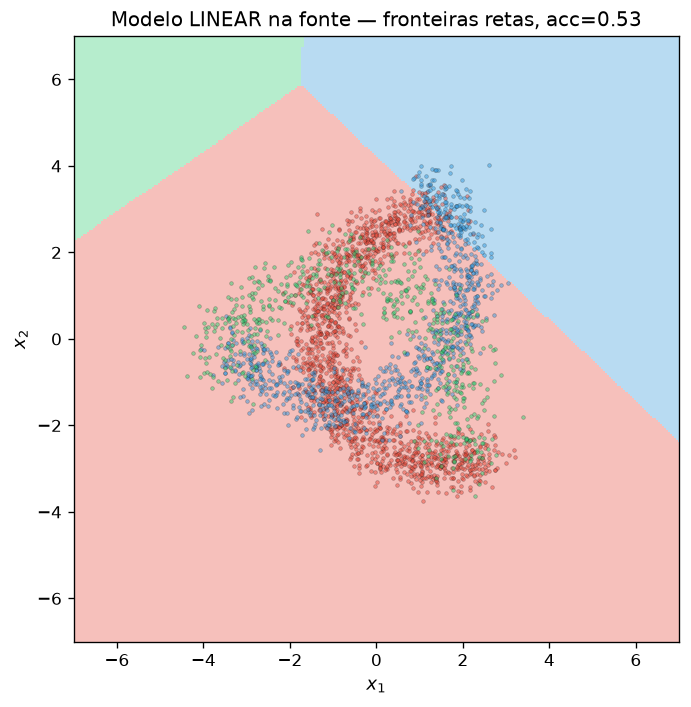

In [8]:
# Regiões de decisão do modelo linear sobre os dados fonte
xs = np.linspace(*XLIM, 300); ys = np.linspace(*YLIM, 300)
gx, gy = np.meshgrid(xs, ys)
grade = np.c_[gx.ravel(), gy.ravel()]
preds_lin = clf_linear.predict(grade).reshape(gx.shape)

cmap_bg = mcolors.ListedColormap([mcolors.to_rgba(c, 0.35) for c in CORES_CLASSES])
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.pcolormesh(gx, gy, preds_lin, cmap=cmap_bg, shading="auto", vmin=0, vmax=N_CLASSES - 1)
Xs, yss = sub_amostra(X_val, y_val, 3000)
for c in range(N_CLASSES):
    m = yss == c
    ax.scatter(Xs[m, 0], Xs[m, 1], s=5, color=CORES_CLASSES[c], edgecolors="k",
               linewidths=0.2, alpha=0.5)
ax.set_title(f"Modelo LINEAR na fonte — fronteiras retas, acc={acc_lin:.2f}")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.set_aspect("equal")
plt.tight_layout()
plt.show()

As fronteiras são **retas** e cortam os arcos ao meio: o modelo linear é
incapaz de acompanhar a geometria curva. **Precisamos de um modelo não-linear.**
Passamos, então, a um **MLP**.

### O classificador de verdade: um MLP (Equinox + Optax)

Mesma receita do Notebook 00. Como as fronteiras são curvas e entrelaçadas,
usamos um MLP `[2 → 64 → 64 → 64 → 3]` com ativação `tanh` e saída linear
(logits para 3 classes). Rico o bastante para os arcos — mas **não perfeito**:
as regiões de sobreposição continuam errando (erro de Bayes).

In [9]:
class Classificador(eqx.Module):
    """MLP classificador com camadas de tamanho variável."""
    layers: list

    def __init__(self, camadas, key):
        self.layers = []
        for i in range(len(camadas) - 1):
            key, subkey = jax.random.split(key)
            self.layers.append(eqx.nn.Linear(camadas[i], camadas[i + 1], key=subkey))

    def __call__(self, x):
        """Forward pass: tanh nas ocultas, linear na saída."""
        for layer in self.layers[:-1]:
            x = jnp.tanh(layer(x))
        return self.layers[-1](x)


CAMADAS = [2, 64, 64, 64, N_CLASSES]
modelo = Classificador(CAMADAS, key=jax.random.PRNGKey(0))

y_teste = jax.vmap(modelo)(X_treino[:3])
print(f"Entrada: shape {X_treino[:3].shape}   Saída (logits): shape {y_teste.shape}")
n_params = sum(jnp.size(p) for p in jax.tree_util.tree_leaves(modelo))
print(f"Total de parâmetros: {n_params}")

Entrada: shape (3, 2)   Saída (logits): shape (3, 3)
Total de parâmetros: 8707


### Entropia cruzada ponderada

Sem pesos, o modelo pode ignorar a classe minoritária (20 %) e ainda ter
acurácia alta. Pesos inversamente proporcionais à frequência forçam o modelo
a levar as classes raras a sério.

In [10]:
# Pesos de classe: inverso da frequência (da FONTE), normalizados
pesos_classe = jnp.array(1.0 / FRACOES_FONTE)
pesos_classe = pesos_classe / pesos_classe.sum() * N_CLASSES
print(f"Pesos de classe: {pesos_classe}")


def perda_ce_ponderada(modelo, x_batch, y_batch, pesos=pesos_classe):
    """Entropia cruzada ponderada por classe."""
    logits = jax.vmap(modelo)(x_batch)
    log_p = jax.nn.log_softmax(logits, axis=-1)
    N = y_batch.shape[0]
    log_py = log_p[jnp.arange(N), y_batch]
    w = pesos[y_batch]
    return -jnp.mean(w * log_py)

Pesos de classe: [0.5806452  0.96774197 1.451613  ]


In [11]:
# Otimizador e passo de treino (modelo fonte)
otimizador = optax.adam(learning_rate=3e-3)
opt_state = otimizador.init(eqx.filter(modelo, eqx.is_array))


@eqx.filter_jit
def passo_treino(modelo, estado, x, y):
    """Um passo: gradiente + atualização Adam."""
    perda, grads = eqx.filter_value_and_grad(perda_ce_ponderada)(modelo, x, y)
    atualizacoes, estado = otimizador.update(grads, estado, modelo)
    modelo = eqx.apply_updates(modelo, atualizacoes)
    return modelo, estado, perda

In [12]:
# Loop de treino com mini-batches
N_EPOCAS = 150
BATCH_SIZE = 256

historico_treino, historico_val = [], []
chave_treino = jax.random.PRNGKey(1)

print(f"Treinando {N_EPOCAS} épocas — Adam (lr=3e-3, batch={BATCH_SIZE})")
for epoca in range(1, N_EPOCAS + 1):
    chave_treino, chave_perm = jax.random.split(chave_treino)
    perm = jax.random.permutation(chave_perm, X_treino.shape[0])
    X_emb, y_emb = X_treino[perm], y_treino[perm]
    for i in range(0, X_treino.shape[0], BATCH_SIZE):
        x_b = X_emb[i:i + BATCH_SIZE]
        y_b = y_emb[i:i + BATCH_SIZE]
        modelo, opt_state, _ = passo_treino(modelo, opt_state, x_b, y_b)
    if epoca % 10 == 0 or epoca == 1:
        p_tr = float(perda_ce_ponderada(modelo, X_treino, y_treino))
        p_va = float(perda_ce_ponderada(modelo, X_val, y_val))
        historico_treino.append((epoca, p_tr))
        historico_val.append((epoca, p_va))
        if epoca <= 1 or epoca % 50 == 0:
            print(f"  Época {epoca:4d}  treino={p_tr:.4f}  val={p_va:.4f}")
print("Treino concluído.")

Treinando 150 épocas — Adam (lr=3e-3, batch=256)


  Época    1  treino=0.4404  val=0.4389


  Época   50  treino=0.3746  val=0.3720


  Época  100  treino=0.3796  val=0.3796


  Época  150  treino=0.3707  val=0.3746
Treino concluído.


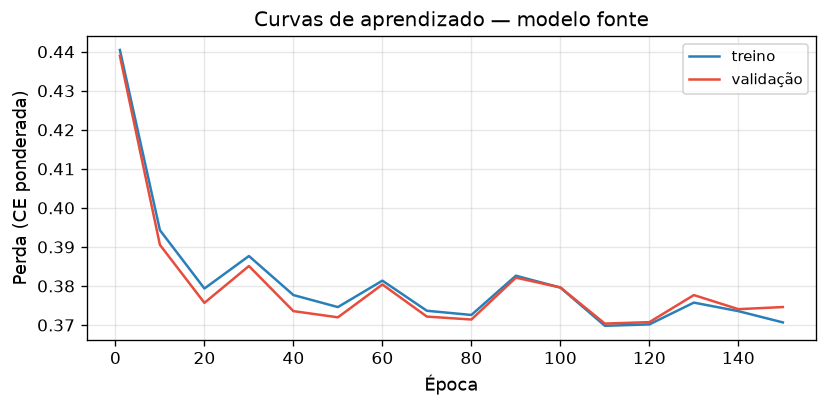

In [13]:
# Curvas de aprendizado
ep_tr, l_tr = zip(*historico_treino)
ep_va, l_va = zip(*historico_val)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(ep_tr, l_tr, "-", lw=1.5, color="#2980b9", label="treino")
ax.plot(ep_va, l_va, "-", lw=1.5, color="#e74c3c", label="validação")
ax.set_xlabel("Época"); ax.set_ylabel("Perda (CE ponderada)")
ax.set_title("Curvas de aprendizado — modelo fonte")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Bloco 3 — Avaliação: visualizações e métricas

O modelo treinou. Agora precisamos **entender** o que ele aprendeu. Quatro
ferramentas, cada uma revelando um aspecto diferente do classificador. Elas
serão **reutilizadas** para medir a degradação e a recuperação mais adiante.

### 3a) Mapa de probabilidade

Avaliamos o modelo numa malha densa cobrindo o espaço 2D. Para cada ponto,
$P(\text{classe } k \mid x)$: mostra o que o modelo **acredita** em cada
região — inclusive onde está confiante mas errado.

In [14]:
def criar_malha(xlim=XLIM, ylim=YLIM, n=300):
    """Cria malha 2D densa (n x n) para avaliação. n alto => contornos suaves."""
    xs = np.linspace(xlim[0], xlim[1], n)
    ys = np.linspace(ylim[0], ylim[1], n)
    return np.meshgrid(xs, ys)


def probabilidades_malha(modelo, xx, yy):
    """Calcula softmax do modelo em todos os pontos da malha."""
    pts = jnp.array(np.c_[xx.ravel(), yy.ravel()], dtype=jnp.float32)
    logits = jax.vmap(modelo)(pts)
    probs = jax.nn.softmax(logits, axis=-1)
    return np.array(probs)


xx, yy = criar_malha(n=300)
probs_malha = probabilidades_malha(modelo, xx, yy)

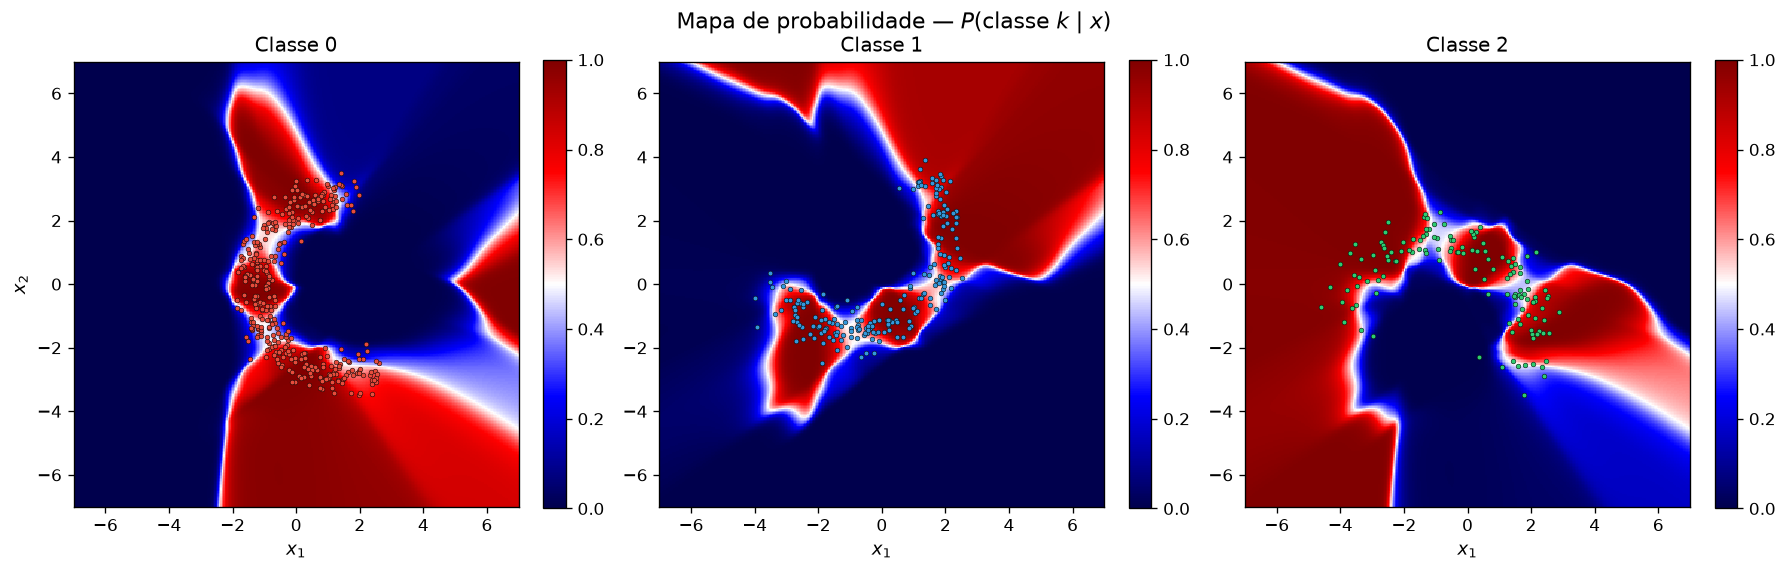

In [15]:
# Mapa de probabilidade — um subpainel por classe
fig, axes = plt.subplots(1, N_CLASSES, figsize=(15, 4.6))
fig.suptitle("Mapa de probabilidade — $P$(classe $k$ | $x$)", fontsize=13)

X_ov, y_ov = sub_amostra(X_val, y_val, 700)
for c in range(N_CLASSES):
    P_c = probs_malha[:, c].reshape(xx.shape)
    im = axes[c].pcolormesh(xx, yy, P_c, cmap="seismic", shading="auto", vmin=0, vmax=1)
    m = y_ov == c
    axes[c].scatter(X_ov[m, 0], X_ov[m, 1], s=8, color=CORES_CLASSES[c],
                    edgecolors="k", linewidths=0.3, zorder=3)
    axes[c].set_title(NOMES_CLASSES[c]); axes[c].set_xlabel("$x_1$")
    axes[c].set_xlim(*XLIM); axes[c].set_ylim(*YLIM); axes[c].set_aspect("equal")
    if c == 0:
        axes[c].set_ylabel("$x_2$")
    plt.colorbar(im, ax=axes[c], fraction=0.046)
plt.tight_layout()
plt.show()

### 3b) Mapa de decisão (regiões de classe)

Aplicamos $\arg\max$ nas probabilidades: cada ponto recebe a classe mais
provável. Mostra as **fronteiras de decisão** aprendidas — agora curvas,
seguindo os arcos.

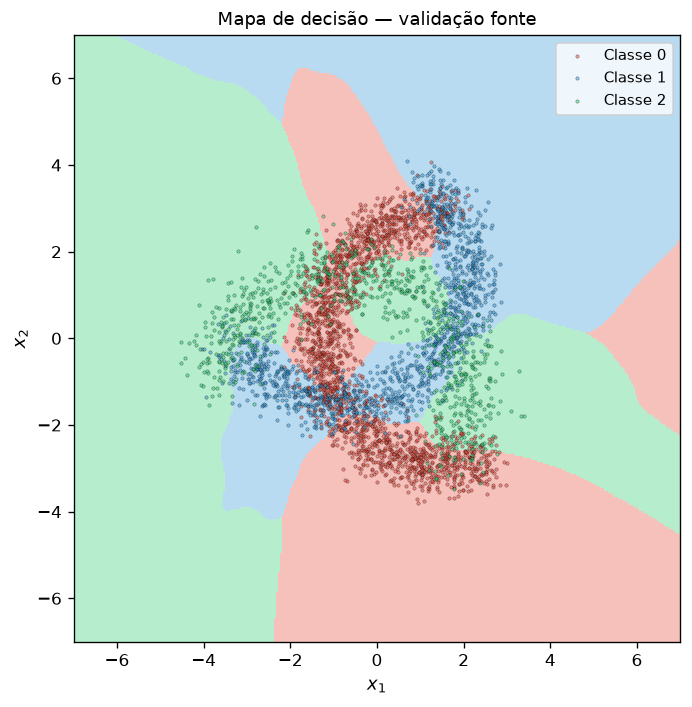

In [16]:
def plotar_mapa_decisao(ax, modelo, X_overlay, y_overlay, titulo, xx, yy,
                        probs=None, alpha_fundo=0.35, n_overlay=4000):
    """Plota regiões de decisão com pontos sobrepostos (cores/limites fixos)."""
    if probs is None:
        probs = probabilidades_malha(modelo, xx, yy)
    preds = probs.argmax(axis=1).reshape(xx.shape)
    cmap_bg = mcolors.ListedColormap(
        [mcolors.to_rgba(c, alpha_fundo) for c in CORES_CLASSES])
    ax.pcolormesh(xx, yy, preds, cmap=cmap_bg, shading="auto", vmin=0, vmax=N_CLASSES - 1)
    Xs, ys = sub_amostra(X_overlay, y_overlay, n_overlay)
    for c in range(N_CLASSES):
        m = ys == c
        ax.scatter(Xs[m, 0], Xs[m, 1], s=4, color=CORES_CLASSES[c], edgecolors="k",
                   alpha=0.5, linewidths=0.3, zorder=3, label=NOMES_CLASSES[c])
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.set_aspect("equal")


fig, ax = plt.subplots(figsize=(6.5, 6))
plotar_mapa_decisao(ax, modelo, X_val, y_val, "Mapa de decisão — validação fonte",
                    xx, yy, probs=probs_malha)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 3c) Matriz de confusão e métricas por classe

A **acurácia** global engana com classes desbalanceadas: prever sempre
"Classe 0" já dá 50 %! Métricas por classe revelam a verdade:

| Métrica | O que mede |
|---------|-----------|
| **TPR** (recall) | Dos exemplos reais da classe, quantos o modelo acertou? |
| **PPV** (precision) | Das predições nessa classe, quantas estavam corretas? |
| **F1** | Média harmônica de TPR e PPV — resume ambos num número |

A métrica-resumo que usaremos nas curvas é o **macro-F1** (média simples dos
F1 por classe): trata todas as classes igualmente, então castiga o modelo que
abandona a minoritária.

In [17]:
def metricas_classificacao(y_true, y_pred, n_classes=N_CLASSES):
    """Matriz de confusão, TPR, PPV e F1 por classe, e acurácia."""
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    cm = np.zeros((n_classes, n_classes), dtype=int)
    np.add.at(cm, (y_true, y_pred), 1)
    tpr = np.zeros(n_classes); ppv = np.zeros(n_classes); f1 = np.zeros(n_classes)
    for c in range(n_classes):
        tp = cm[c, c]
        fn = cm[c, :].sum() - tp
        fp = cm[:, c].sum() - tp
        tpr[c] = tp / max(tp + fn, 1)
        ppv[c] = tp / max(tp + fp, 1)
        if tpr[c] + ppv[c] > 0:
            f1[c] = 2 * tpr[c] * ppv[c] / (tpr[c] + ppv[c])
    acc = np.trace(cm) / max(cm.sum(), 1)
    return cm, tpr, ppv, f1, acc


def macro_f1_modelo(modelo, X, y):
    """Atalho: macro-F1 de um modelo Equinox sobre (X, y)."""
    preds = np.array(jnp.argmax(jax.vmap(modelo)(X), axis=-1))
    _, _, _, f1, _ = metricas_classificacao(np.asarray(y), preds)
    return float(f1.mean())


def plotar_matriz_confusao(ax, cm, titulo):
    """Matriz de confusão normalizada por linha (com contagens)."""
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    ax.imshow(cm_norm, cmap="Blues", aspect="equal", vmin=0, vmax=1)
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel("Predito"); ax.set_ylabel("Real")
    ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels([f"C{c}" for c in range(N_CLASSES)], fontsize=9)
    ax.set_yticklabels([f"C{c}" for c in range(N_CLASSES)], fontsize=9)
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            cor = "white" if cm_norm[i, j] > 0.5 else "black"
            ax.text(j, i, f"{cm[i, j]}\n({cm_norm[i, j]:.0%})", ha="center",
                    va="center", color=cor, fontsize=8)

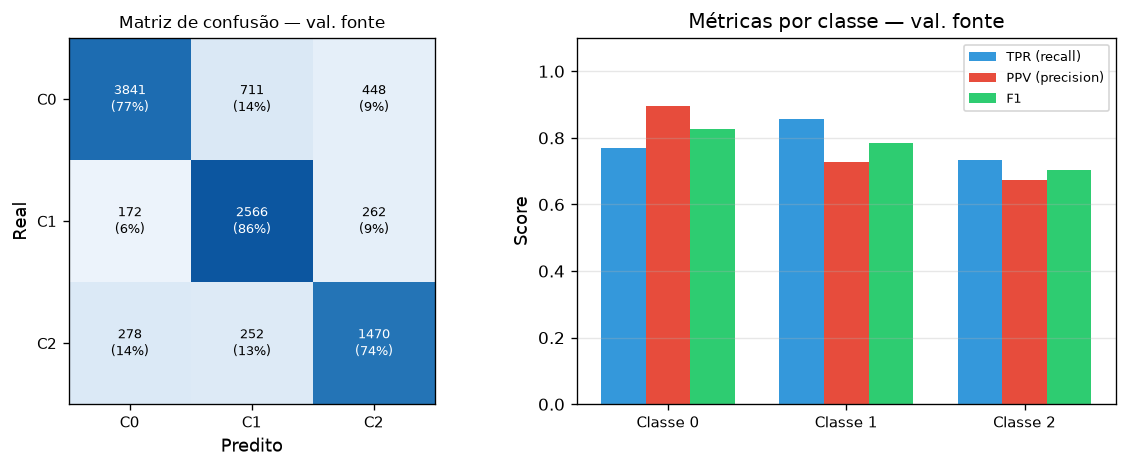

Acurácia global: 0.788
Macro-F1       : 0.772
  Classe 0: TPR=0.768  PPV=0.895  F1=0.827
  Classe 1: TPR=0.855  PPV=0.727  F1=0.786
  Classe 2: TPR=0.735  PPV=0.674  F1=0.703


In [18]:
# Predições no conjunto de validação fonte
preds_val_fonte = np.array(jnp.argmax(jax.vmap(modelo)(X_val), axis=-1))
cm_fonte, tpr_fonte, ppv_fonte, f1_fonte, acc_fonte = metricas_classificacao(
    np.array(y_val), preds_val_fonte)
F1_FONTE = float(f1_fonte.mean())  # referência usada em todo o notebook

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plotar_matriz_confusao(ax1, cm_fonte, "Matriz de confusão — val. fonte")
x_pos = np.arange(N_CLASSES); largura = 0.25
ax2.bar(x_pos - largura, tpr_fonte, largura, label="TPR (recall)", color="#3498db")
ax2.bar(x_pos, ppv_fonte, largura, label="PPV (precision)", color="#e74c3c")
ax2.bar(x_pos + largura, f1_fonte, largura, label="F1", color="#2ecc71")
ax2.set_xticks(x_pos); ax2.set_xticklabels(NOMES_CLASSES, fontsize=9)
ax2.set_ylim(0, 1.1); ax2.set_ylabel("Score")
ax2.set_title("Métricas por classe — val. fonte")
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print(f"Acurácia global: {acc_fonte:.3f}")
print(f"Macro-F1       : {F1_FONTE:.3f}")
for c in range(N_CLASSES):
    print(f"  {NOMES_CLASSES[c]}: TPR={tpr_fonte[c]:.3f}  "
          f"PPV={ppv_fonte[c]:.3f}  F1={f1_fonte[c]:.3f}")

### 3d) Curva ROC e AUC (por classe, one-vs-rest)

A ROC mostra o trade-off entre TPR e taxa de falso positivo (FPR) ao variar
o limiar. **AUC = 1.0**: separação perfeita; **AUC = 0.5**: aleatório. Ela
captura quão bem o modelo *ordena* as probabilidades, independente do limiar.

In [19]:
def calcular_roc_auc(y_true, probs, n_classes=N_CLASSES):
    """Curva ROC e AUC por classe (one-vs-rest), vetorizado e à prova de degeneração."""
    y_true = np.asarray(y_true); probs = np.asarray(probs)
    resultados = []
    for c in range(n_classes):
        y_bin = (y_true == c).astype(int)
        if y_bin.sum() == 0 or y_bin.sum() == len(y_bin):
            resultados.append({"fpr": None, "tpr": None, "auc": None})
            continue
        scores = probs[:, c]
        ordem = np.argsort(-scores)
        y_sorted = y_bin[ordem]; scores_sorted = scores[ordem]
        n_pos = y_bin.sum(); n_neg = len(y_bin) - n_pos
        tp_acum = np.cumsum(y_sorted); fp_acum = np.cumsum(1 - y_sorted)
        ultimo = np.r_[scores_sorted[:-1] != scores_sorted[1:], True]
        tpr_arr = np.r_[0.0, tp_acum[ultimo] / n_pos]
        fpr_arr = np.r_[0.0, fp_acum[ultimo] / n_neg]
        auc_val = float(np.trapezoid(tpr_arr, fpr_arr))
        resultados.append({"fpr": fpr_arr, "tpr": tpr_arr, "auc": auc_val})
    return resultados


def plotar_roc(ax, roc_resultados, titulo):
    """Plota curvas ROC por classe num eixo."""
    for c in range(N_CLASSES):
        r = roc_resultados[c]
        if r["auc"] is not None:
            ax.plot(r["fpr"], r["tpr"], lw=2, color=CORES_CLASSES[c],
                    label=f'{NOMES_CLASSES[c]} (AUC={r["auc"]:.3f})')
    ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Aleatório (0.5)")
    ax.set_xlabel("Taxa de Falso Positivo (FPR)")
    ax.set_ylabel("Taxa de Verdadeiro Positivo (TPR)")
    ax.set_title(titulo); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.set_aspect("equal")

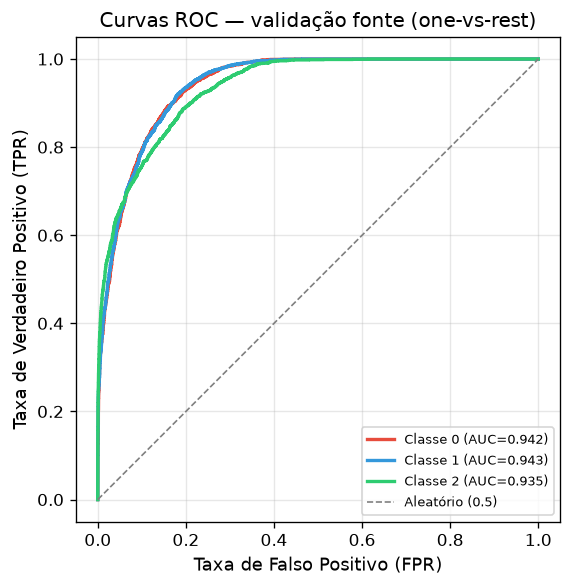

  Classe 0: AUC = 0.942
  Classe 1: AUC = 0.943
  Classe 2: AUC = 0.935
Verificação OK: todos os AUC finitos.


In [20]:
# ROC/AUC para o modelo fonte na validação
probs_val_fonte = np.array(jax.nn.softmax(jax.vmap(modelo)(X_val), axis=-1))
roc_fonte = calcular_roc_auc(np.array(y_val), probs_val_fonte)

fig, ax = plt.subplots(figsize=(5.5, 5))
plotar_roc(ax, roc_fonte, "Curvas ROC — validação fonte (one-vs-rest)")
plt.tight_layout()
plt.show()

for c in range(N_CLASSES):
    auc_val = roc_fonte[c]["auc"]
    assert auc_val is not None and np.isfinite(auc_val), f"AUC degenerado na classe {c}!"
    print(f"  {NOMES_CLASSES[c]}: AUC = {auc_val:.3f}")
print("Verificação OK: todos os AUC finitos.")

---
## Bloco 4 — O botão do shift: degradação em função do ângulo de rotação

Agora introduzimos o domain shift da forma mais controlada possível: **giramos
o domínio** por um ângulo $\theta$ em torno da origem. Um único número, uma
deformação interpretável. Primeiro *vemos* o shift crescer; depois *medimos*
a degradação em função de $\theta$ e escolhemos **um ângulo de trabalho**.

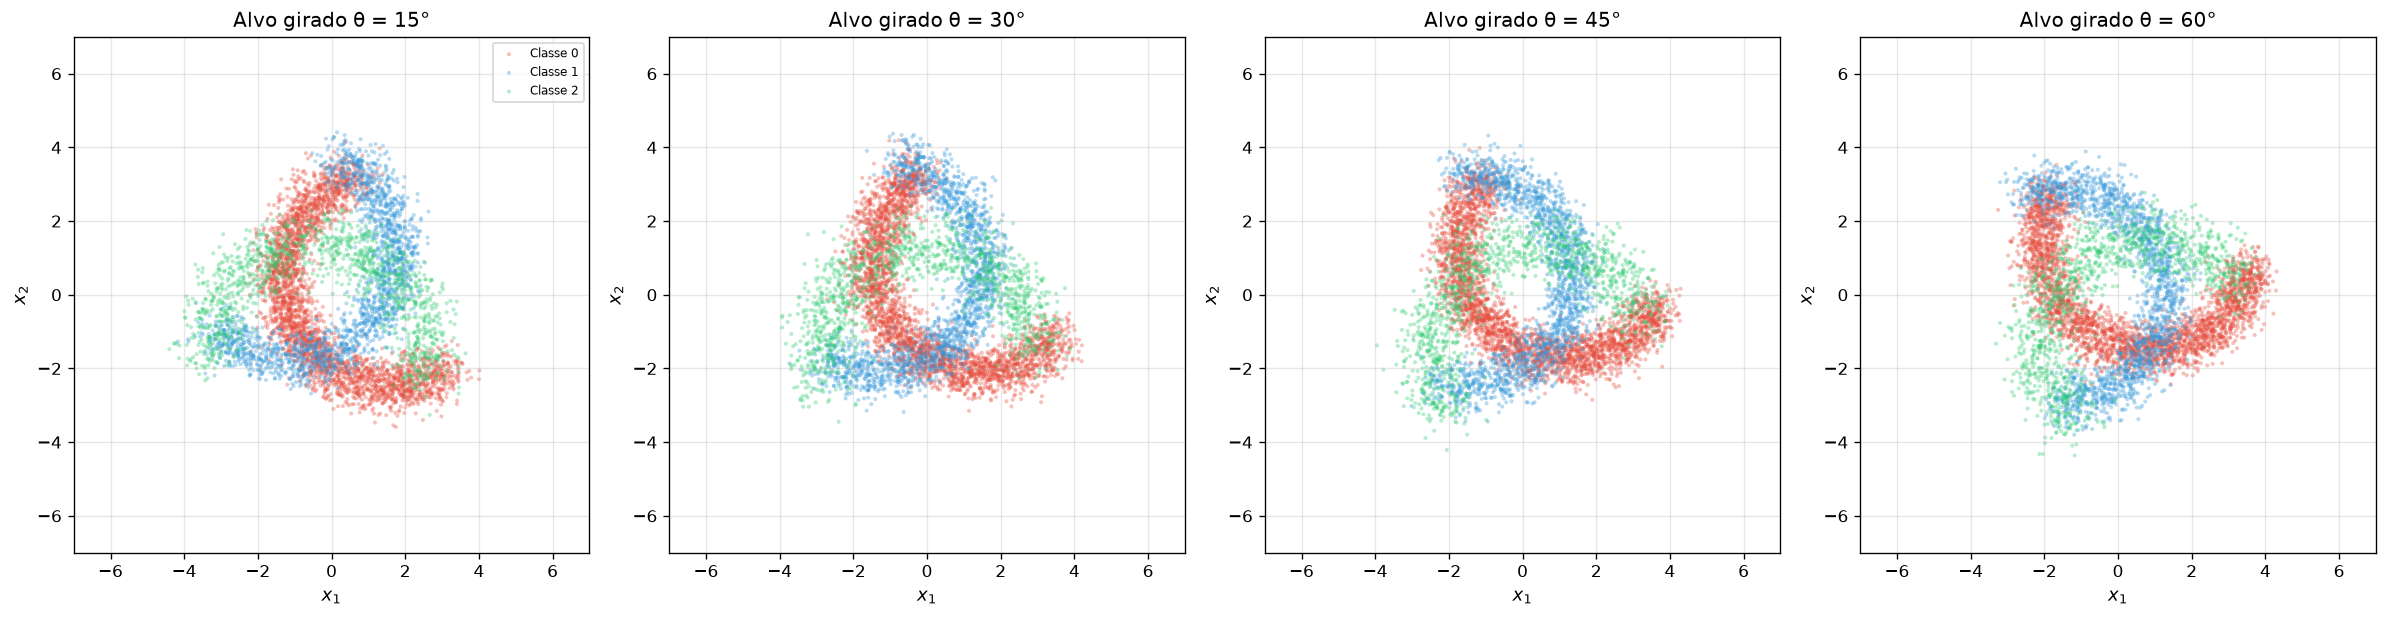

In [21]:
# O alvo em alguns ângulos — o shift crescendo (mesma config, só girando)
angulos_preview = [15, 30, 45, 60]
fig, axes = plt.subplots(1, len(angulos_preview), figsize=(20, 5))
for ax, th in zip(axes, angulos_preview):
    key_prev, KEY = jax.random.split(KEY)
    Xp, yp = gerar_dominio(CONFIG_FONTE, 6000, key_prev, theta_graus=th)
    scatter_classes(ax, Xp, yp, f"Alvo girado θ = {th}°", n_max=6000)
axes[0].legend(loc="upper right", fontsize=7)
plt.tight_layout()
plt.show()

### Curva de degradação: macro-F1 do modelo fonte vs. ângulo

O modelo **não muda**. Só variamos $\theta$ do alvo e reavaliamos. A literatura
reporta degradação **monótona** com o ângulo para modelos não-adaptados — é
exatamente o que devemos ver (até ~60°, onde o desalinhamento é máximo por
causa da simetria de 120° do arranjo).

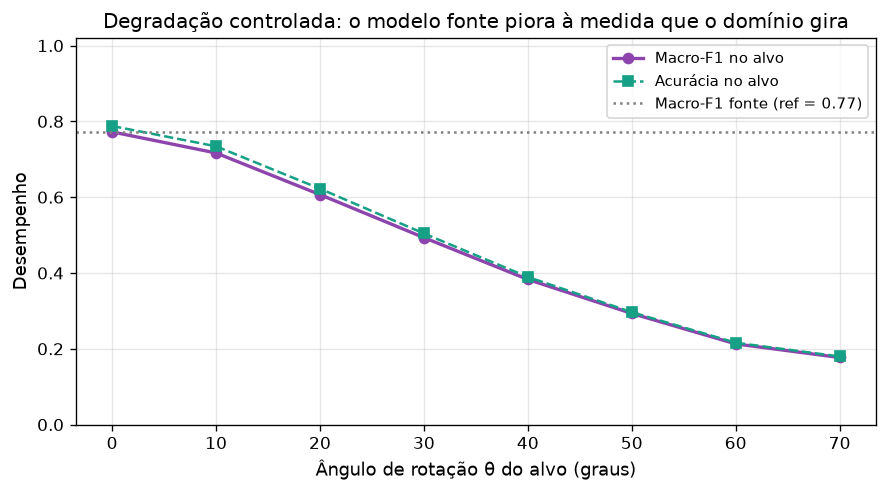

  θ=  0°  macro-F1=0.772
  θ= 10°  macro-F1=0.717
  θ= 20°  macro-F1=0.607
  θ= 30°  macro-F1=0.493
  θ= 40°  macro-F1=0.383
  θ= 50°  macro-F1=0.293
  θ= 60°  macro-F1=0.213
  θ= 70°  macro-F1=0.177


In [22]:
angulos_sweep = np.arange(0, 71, 10)
f1_por_angulo, acc_por_angulo = [], []
for th in angulos_sweep:
    key_a, KEY = jax.random.split(KEY)
    X_th, y_th = gerar_dominio(CONFIG_FONTE, 8000, key_a, theta_graus=float(th))
    preds_th = np.array(jnp.argmax(jax.vmap(modelo)(X_th), axis=-1))
    _, _, _, f1_th, acc_th = metricas_classificacao(np.array(y_th), preds_th)
    f1_por_angulo.append(float(f1_th.mean()))
    acc_por_angulo.append(float(acc_th))

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(angulos_sweep, f1_por_angulo, "o-", lw=2, color="#8e44ad", label="Macro-F1 no alvo")
ax.plot(angulos_sweep, acc_por_angulo, "s--", lw=1.5, color="#16a085", label="Acurácia no alvo")
ax.axhline(F1_FONTE, ls=":", color="gray", label=f"Macro-F1 fonte (ref = {F1_FONTE:.2f})")
ax.set_xlabel("Ângulo de rotação θ do alvo (graus)")
ax.set_ylabel("Desempenho")
ax.set_title("Degradação controlada: o modelo fonte piora à medida que o domínio gira")
ax.set_ylim(0, 1.02); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for th, f1v in zip(angulos_sweep, f1_por_angulo):
    print(f"  θ={th:3d}°  macro-F1={f1v:.3f}")

### Escolha do ângulo de trabalho

Escolhemos **θ = 30°**. A degradação já é clara e inegável — o macro-F1 despenca
de ~0.77 para ~0.49, quase **pela metade** — mas o giro é **moderado**: o
problema continua *reconhecidamente o mesmo* e, crucial para o Bloco 6, as
*features* do modelo fonte ainda são **parcialmente aproveitáveis**. Um giro
grande demais (50-60°) destruiria tanto o desempenho que nem o pré-treino
ajudaria; um giro pequeno demais nem seria um shift interessante. Sobre esse
giro moderado **empilhamos perturbações mais fortes** (tabela abaixo), então o
dano *zero-shot* é grande sem precisar de um giro extremo.

**Além do giro**, tornamos o shift mais realista adicionando ao alvo:

| Classe | Perturbação extra | Tipo de shift (L2B1) |
|--------|-------------------|----------------------|
| 0 | ruído um pouco maior | *covariate shift* |
| 1 | praticamente inalterada | (quase nada) |
| 2 (minoritária) | bem mais **espessa e difusa** | *covariate shift* forte |
| todas | proporções 50/30/20 → 35/35/30 | ***prior shift*** |

Ou seja: **rotação + covariate shift heterogêneo + prior shift** agindo juntos.
O dano será **desigual entre as classes** — a minoritária sofre mais.

In [23]:
THETA_TRAB = 30.0  # ângulo de trabalho (graus)

CONFIG_ALVO = [
    {"nome": "Classe 0", "cor": CORES_CLASSES[0], "fracao": 0.35,
     "params": _arco_params(0, esp=0.34, ruido=0.40)},   # ruído maior
    {"nome": "Classe 1", "cor": CORES_CLASSES[1], "fracao": 0.35,
     "params": _arco_params(1, esp=0.34, ruido=0.30)},   # quase igual
    {"nome": "Classe 2", "cor": CORES_CLASSES[2], "fracao": 0.30,
     "params": _arco_params(2, esp=0.62, ruido=0.55)},   # muito mais difusa
]
FRACOES_ALVO = np.array([s["fracao"] for s in CONFIG_ALVO])

In [24]:
# Gerar dados do alvo no ângulo de trabalho: treino (pool de rótulos) + validação
N_ALVO_TR = 20_000
N_ALVO_VAL = 10_000

key_tgt_tr, key_tgt_val, KEY = jax.random.split(KEY, 3)
X_alvo_tr, y_alvo_tr = gerar_dominio(CONFIG_ALVO, N_ALVO_TR, key_tgt_tr, theta_graus=THETA_TRAB)
X_alvo_val, y_alvo_val = gerar_dominio(CONFIG_ALVO, N_ALVO_VAL, key_tgt_val, theta_graus=THETA_TRAB)

resumo_split("Treino alvo", y_alvo_tr)
resumo_split("Validação alvo", y_alvo_val)
print("\nProporções (prior shift):")
for c in range(N_CLASSES):
    print(f"  {NOMES_CLASSES[c]}: fonte {FRACOES_FONTE[c]:.0%}  ->  alvo {FRACOES_ALVO[c]:.0%}")

Treino alvo: 20000 pontos
  Classe 0:   7000  (35.0%)
  Classe 1:   7000  (35.0%)
  Classe 2:   6000  (30.0%)
Validação alvo: 10000 pontos
  Classe 0:   3500  (35.0%)
  Classe 1:   3500  (35.0%)
  Classe 2:   3000  (30.0%)

Proporções (prior shift):
  Classe 0: fonte 50%  ->  alvo 35%
  Classe 1: fonte 30%  ->  alvo 35%
  Classe 2: fonte 20%  ->  alvo 30%


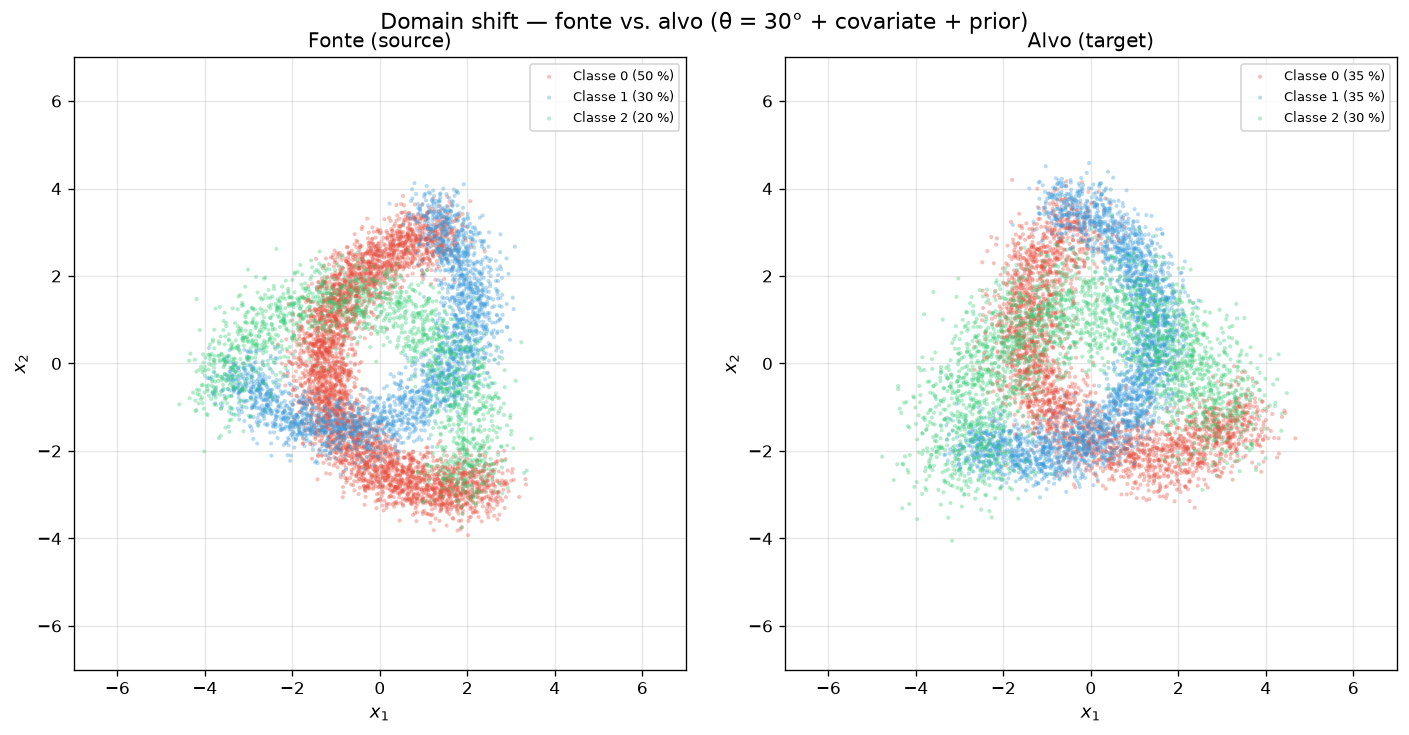

In [25]:
# Figura fonte -> alvo (mesmos limites de eixo)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle(f"Domain shift — fonte vs. alvo (θ = {THETA_TRAB:.0f}° + covariate + prior)",
             fontsize=13)
scatter_classes(axes[0], X_treino, y_treino, "Fonte (source)", fracoes=FRACOES_FONTE)
axes[0].legend(loc="upper right", fontsize=8)
scatter_classes(axes[1], X_alvo_val, y_alvo_val, "Alvo (target)", fracoes=FRACOES_ALVO)
axes[1].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

---
## Bloco 5 — Zero-shot: quanto o modelo fonte se degrada no alvo

Aplicamos o modelo fonte, **sem nenhuma modificação**, ao alvo no ângulo de
trabalho. Isto é o cenário **zero-shot** (nenhum rótulo do alvo). Reutilizamos
as ferramentas do Bloco 3 para medir o estrago.

In [26]:
preds_alvo = np.array(jnp.argmax(jax.vmap(modelo)(X_alvo_val), axis=-1))
cm_alvo, tpr_alvo, ppv_alvo, f1_alvo, acc_alvo = metricas_classificacao(
    np.array(y_alvo_val), preds_alvo)
F1_ZEROSHOT = float(f1_alvo.mean())

print("=== Modelo fonte aplicado ao ALVO (zero-shot) ===")
print(f"Acurácia: {acc_alvo:.3f}  (fonte: {acc_fonte:.3f})")
print(f"Macro-F1: {F1_ZEROSHOT:.3f}  (fonte: {F1_FONTE:.3f})")
print()
for c in range(N_CLASSES):
    print(f"  {NOMES_CLASSES[c]}: TPR={tpr_alvo[c]:.3f} (fonte {tpr_fonte[c]:.3f})  "
          f"F1={f1_alvo[c]:.3f} (fonte {f1_fonte[c]:.3f})")

=== Modelo fonte aplicado ao ALVO (zero-shot) ===
Acurácia: 0.504  (fonte: 0.788)
Macro-F1: 0.504  (fonte: 0.772)

  Classe 0: TPR=0.472 (fonte 0.768)  F1=0.481 (fonte 0.827)
  Classe 1: TPR=0.527 (fonte 0.855)  F1=0.543 (fonte 0.786)
  Classe 2: TPR=0.515 (fonte 0.735)  F1=0.488 (fonte 0.703)


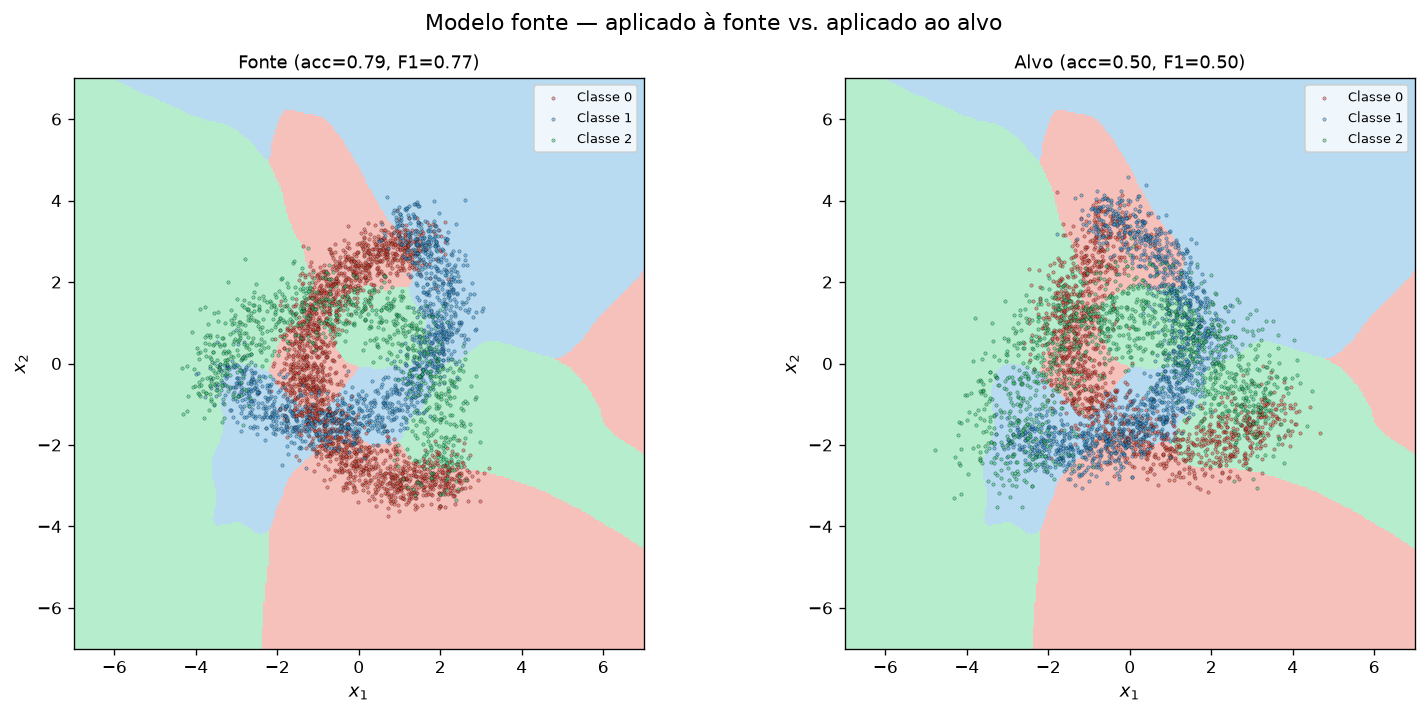

In [27]:
# Mapas de decisão: as MESMAS fronteiras, dados diferentes
probs_malha_fonte = probs_malha
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle("Modelo fonte — aplicado à fonte vs. aplicado ao alvo", fontsize=13)
plotar_mapa_decisao(ax1, modelo, X_val, y_val,
                    f"Fonte (acc={acc_fonte:.2f}, F1={F1_FONTE:.2f})",
                    xx, yy, probs=probs_malha_fonte)
ax1.legend(fontsize=8, loc="upper right")
plotar_mapa_decisao(ax2, modelo, X_alvo_val, y_alvo_val,
                    f"Alvo (acc={acc_alvo:.2f}, F1={F1_ZEROSHOT:.2f})",
                    xx, yy, probs=probs_malha_fonte)
ax2.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

As fronteiras **não mudaram** (o modelo é o mesmo), mas os arcos do alvo
giraram para regiões que o modelo atribui a **outra** classe. Ele fica
**confiante e errado** — o pior cenário. Vamos ver isso na confusão e na ROC.

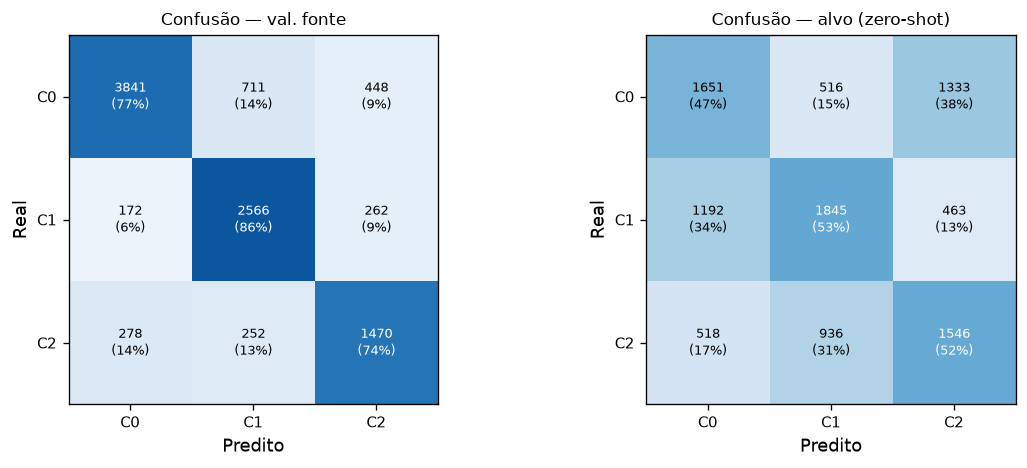

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plotar_matriz_confusao(ax1, cm_fonte, "Confusão — val. fonte")
plotar_matriz_confusao(ax2, cm_alvo, "Confusão — alvo (zero-shot)")
plt.tight_layout()
plt.show()

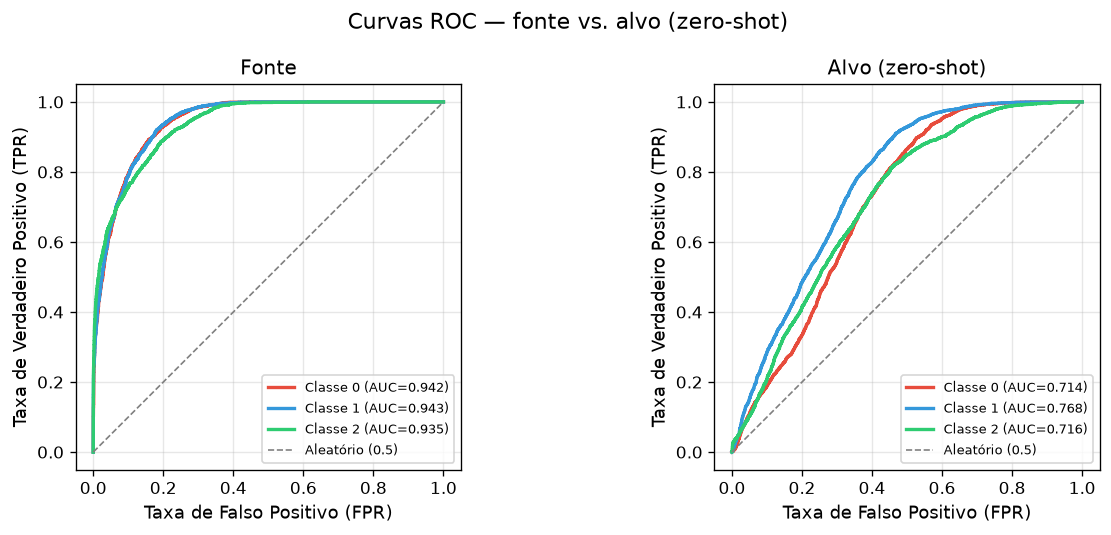


Resumo AUC:
Classe          Fonte     Alvo    Delta
Classe 0        0.942    0.714   -0.229
Classe 1        0.943    0.768   -0.175
Classe 2        0.935    0.716   -0.219


In [29]:
probs_alvo_full = np.array(jax.nn.softmax(jax.vmap(modelo)(X_alvo_val), axis=-1))
roc_alvo = calcular_roc_auc(np.array(y_alvo_val), probs_alvo_full)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle("Curvas ROC — fonte vs. alvo (zero-shot)", fontsize=13)
plotar_roc(ax1, roc_fonte, "Fonte")
plotar_roc(ax2, roc_alvo, "Alvo (zero-shot)")
plt.tight_layout()
plt.show()

print("\nResumo AUC:")
print(f"{'Classe':<12} {'Fonte':>8} {'Alvo':>8} {'Delta':>8}")
for c in range(N_CLASSES):
    a_f = roc_fonte[c]["auc"] or 0
    a_a = roc_alvo[c]["auc"] or 0
    print(f"{NOMES_CLASSES[c]:<12} {a_f:>8.3f} {a_a:>8.3f} {a_a - a_f:>+8.3f}")

---
## Bloco 6 — Fine-tuning compra **eficiência de rótulos**

Este é o bloco que dá razão de existir ao notebook. Temos um modelo que funciona
na fonte e falha no alvo. Quanto vale um modelo **pré-treinado**? Comparamos três
regimes em função do número de **rótulos do alvo** $K$:

- **(A) Zero-shot** — modelo fonte aplicado ao alvo, **0 rótulos** (não depende de $K$);
- **(B) Do zero** — um modelo novo treinado **só** nos $K$ rótulos do alvo;
- **(C) Fine-tuned** — o modelo fonte, **re-treinado** nos mesmos $K$ rótulos.

**Comparação justa:** B e C usam a *mesma* arquitetura, o *mesmo* número de
passos e a mesma amostra de $K$ rótulos. As diferenças são exatamente as duas
que **definem** o fine-tuning: (i) o **ponto de partida** — B começa aleatório,
C começa do modelo fonte; e (ii) um **learning rate mais suave** em C, para
*preservar* o que a fonte já ensinou (um passo grande demais "reiniciaria" o
modelo e jogaria fora o pré-treino — ver Exercício 3).

In [30]:
# --- Motor de treino compartilhado para o sweep (full-batch, JIT em cache) ---
# Passos e otimizadores em nível de módulo => o JIT recompila poucas vezes
# (uma por forma de K e por conjunto de parâmetros treináveis), reaproveitando
# entre B, C, D e entre as sementes. Mantém o sweep barato na CPU.
#
# DOIS learning rates, de propósito (é isto que distingue "treinar" de "adaptar"):
LR_SCRATCH = 3e-3      # do zero: precisa aprender depressa, partindo do nada
LR_FT = 5e-4           # fine-tuning: passo suave, para NÃO apagar o pré-treino
N_STEPS_SWEEP = 300    # mesmo orçamento de passos para todos os regimes
OPT_SCRATCH = optax.adam(LR_SCRATCH)
OPT_FT = optax.adam(LR_FT)


def filtro_treinavel(modelo, so_ultima):
    """filter_spec booleano: True nos parâmetros treináveis.

    so_ultima=False -> todos os pesos; True -> só a última camada (o "cabeçalho").
    """
    if not so_ultima:
        return jax.tree_util.tree_map(lambda a: True, modelo)
    spec = jax.tree_util.tree_map(lambda a: False, modelo)
    n = len(modelo.layers)
    spec = eqx.tree_at(
        lambda m: m.layers[n - 1], spec,
        replace=jax.tree_util.tree_map(lambda a: True, modelo.layers[n - 1]))
    return spec


def _fabricar_passo(otim):
    """Cria um passo full-batch JIT-compilado para um otimizador dado."""
    @eqx.filter_jit
    def passo(trainable, static, opt_state, X, y, pesos):
        def lf(tr):
            return perda_ce_ponderada(eqx.combine(tr, static), X, y, pesos)
        l, g = eqx.filter_value_and_grad(lf)(trainable)
        upd, opt_state = otim.update(g, opt_state, trainable)
        return eqx.apply_updates(trainable, upd), opt_state, l
    return passo


_passo_scratch = _fabricar_passo(OPT_SCRATCH)
_passo_ft = _fabricar_passo(OPT_FT)


def treinar_sweep(modelo_init, X, y, passo, otim, so_ultima=False,
                  pesos=pesos_classe, n_steps=N_STEPS_SWEEP):
    """Treina (full-batch) partindo de `modelo_init`. Retorna o modelo treinado."""
    spec = filtro_treinavel(modelo_init, so_ultima)
    trainable, static = eqx.partition(modelo_init, spec)
    opt_state = otim.init(trainable)
    for _ in range(n_steps):
        trainable, opt_state, _ = passo(trainable, static, opt_state, X, y, pesos)
    return eqx.combine(trainable, static)


def amostrar_k_rotulos(X, y, K, chave):
    """Amostra ~K pontos rotulados, estratificado por classe."""
    k_por_classe = max(2, K // N_CLASSES)
    idx_list = []
    for c in range(N_CLASSES):
        idx_c = jnp.where(y == c)[0]
        chave, k = jax.random.split(chave)
        escolhidos = jax.random.permutation(k, idx_c.shape[0])[:k_por_classe]
        idx_list.append(idx_c[escolhidos])
    idx = jnp.concatenate(idx_list)
    return X[idx], y[idx]

In [31]:
# --- O sweep: para cada K, treinar B (do zero), C (fine-tune total) e
#     D (fine-tune só da última camada), com poucas sementes para suavizar. ---
K_GRID = [10, 25, 50, 100, 250, 500, 1000, 2500]
N_SEEDS = 5  # média sobre sementes -> curva suave (K pequeno tem alta variância)

f1_scratch, f1_ft_full, f1_ft_last = [], [], []
print("Sweep de K (isto retreina vários modelos pequenos)...")
for K in K_GRID:
    b_s, c_s, d_s = [], [], []
    for seed in range(N_SEEDS):
        key_k = jax.random.PRNGKey(1000 * seed + K)
        key_amostra, key_init = jax.random.split(key_k)
        Xk, yk = amostrar_k_rotulos(X_alvo_tr, y_alvo_tr, K, key_amostra)
        # (B) do zero: mesma arquitetura, init aleatório, lr alto
        m_b = treinar_sweep(Classificador(CAMADAS, key=key_init), Xk, yk,
                            _passo_scratch, OPT_SCRATCH)
        # (C) fine-tune total: parte do modelo fonte, lr suave
        m_c = treinar_sweep(modelo, Xk, yk, _passo_ft, OPT_FT)
        # (D) fine-tune só da última camada (cabeçalho) — lr alto, só o "head"
        m_d = treinar_sweep(modelo, Xk, yk, _passo_scratch, OPT_SCRATCH, so_ultima=True)
        b_s.append(macro_f1_modelo(m_b, X_alvo_val, y_alvo_val))
        c_s.append(macro_f1_modelo(m_c, X_alvo_val, y_alvo_val))
        d_s.append(macro_f1_modelo(m_d, X_alvo_val, y_alvo_val))
    f1_scratch.append(np.mean(b_s))
    f1_ft_full.append(np.mean(c_s))
    f1_ft_last.append(np.mean(d_s))
    print(f"  K={K:5d}  do-zero={f1_scratch[-1]:.3f}  "
          f"ft-total={f1_ft_full[-1]:.3f}  ft-última={f1_ft_last[-1]:.3f}")

Sweep de K (isto retreina vários modelos pequenos)...


  K=   10  do-zero=0.459  ft-total=0.572  ft-última=0.528


  K=   25  do-zero=0.573  ft-total=0.625  ft-última=0.598


  K=   50  do-zero=0.642  ft-total=0.659  ft-última=0.620


  K=  100  do-zero=0.660  ft-total=0.685  ft-última=0.666


  K=  250  do-zero=0.670  ft-total=0.681  ft-última=0.647


  K=  500  do-zero=0.692  ft-total=0.687  ft-última=0.658


  K= 1000  do-zero=0.701  ft-total=0.699  ft-última=0.675


  K= 2500  do-zero=0.699  ft-total=0.692  ft-última=0.667


### A figura-chave: macro-F1 vs. número de rótulos $K$

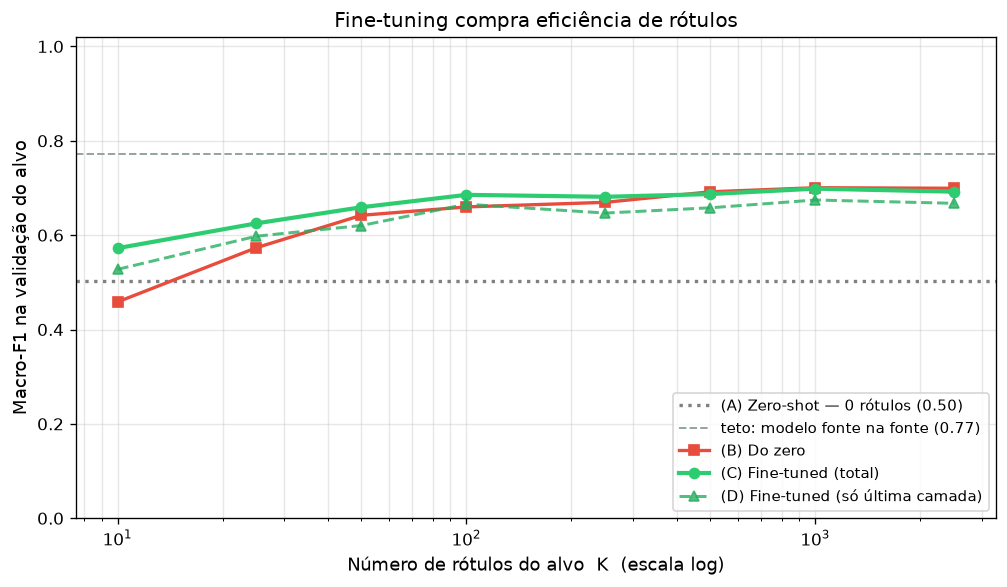

In [32]:
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.axhline(F1_ZEROSHOT, ls=":", lw=2, color="gray",
           label=f"(A) Zero-shot — 0 rótulos ({F1_ZEROSHOT:.2f})")
ax.axhline(F1_FONTE, ls="--", lw=1.2, color="#95a5a6",
           label=f"teto: modelo fonte na fonte ({F1_FONTE:.2f})")
ax.plot(K_GRID, f1_scratch, "s-", lw=2, color="#e74c3c", label="(B) Do zero")
ax.plot(K_GRID, f1_ft_full, "o-", lw=2.5, color="#2ecc71", label="(C) Fine-tuned (total)")
ax.plot(K_GRID, f1_ft_last, "^--", lw=1.8, color="#27ae60", alpha=0.8,
        label="(D) Fine-tuned (só última camada)")
ax.set_xscale("log")
ax.set_xlabel("Número de rótulos do alvo  K  (escala log)")
ax.set_ylabel("Macro-F1 na validação do alvo")
ax.set_title("Fine-tuning compra eficiência de rótulos")
ax.set_ylim(0, 1.02); ax.legend(loc="lower right"); ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()

**A lição central.** Com **poucos** rótulos, a curva (C) fine-tuned está muito
acima de (B) do zero: o modelo do zero não tem dados suficientes para reaprender
a geometria curva e **sobreajusta**. O modelo pré-treinado já *conhece a forma*
do problema — basta reorientá-la. Só quando $K$ fica **grande** é que o do-zero
alcança o fine-tuned.

> Pré-treinar não economiza só *tempo*: economiza **rótulos** — e rótulos são o
> recurso caro (ligação com L2B1).

E o fine-tuning só da **última camada** (D)? É o mais barato (adapta poucos
parâmetros), mas aqui **estaciona abaixo** do fine-tuning total: como o **giro
desalinhou as *features* do backbone**, congelá-las limita o ganho. Lição: às
vezes é preciso **adaptar o backbone**, não só re-treinar o cabeçalho.

### Custo da adaptação: esquecimento catastrófico

Adaptar tem um preço. Depois de fazer fine-tuning no alvo, quanto o modelo
**perde na fonte**? Comparamos, num $K$ pequeno, o fine-tuning **total** vs. o
de **só a última camada** — reavaliando ambos de volta no domínio **fonte**.

In [33]:
K_DEMO = 50
key_demo = jax.random.PRNGKey(2024)
key_am, key_bi = jax.random.split(key_demo)
X_demo, y_demo = amostrar_k_rotulos(X_alvo_tr, y_alvo_tr, K_DEMO, key_am)

modelo_scratch = treinar_sweep(Classificador(CAMADAS, key=key_bi), X_demo, y_demo,
                               _passo_scratch, OPT_SCRATCH)
modelo_ft = treinar_sweep(modelo, X_demo, y_demo, _passo_ft, OPT_FT)          # total
modelo_ft_last = treinar_sweep(modelo, X_demo, y_demo, _passo_scratch,
                               OPT_SCRATCH, so_ultima=True)                    # só última

# Macro-F1 no ALVO e na FONTE para cada modelo
linhas = [
    ("Fonte (pré-treino)", macro_f1_modelo(modelo, X_alvo_val, y_alvo_val), F1_FONTE),
    ("Fine-tune total",    macro_f1_modelo(modelo_ft, X_alvo_val, y_alvo_val),
                           macro_f1_modelo(modelo_ft, X_val, y_val)),
    ("Fine-tune última",   macro_f1_modelo(modelo_ft_last, X_alvo_val, y_alvo_val),
                           macro_f1_modelo(modelo_ft_last, X_val, y_val)),
]

print(f"=== Esquecimento catastrófico (K = {K_DEMO}) ===")
print(f"{'Modelo':<20} {'F1 ALVO':>9} {'F1 FONTE':>10}")
for nome, f1a, f1s in linhas:
    print(f"{nome:<20} {f1a:>9.3f} {f1s:>10.3f}")
FORGET_DROP = F1_FONTE - linhas[1][2]
print(f"\nQueda na FONTE após fine-tune total: {F1_FONTE:.3f} -> {linhas[1][2]:.3f} "
      f"(Δ = {FORGET_DROP:+.3f})")
print("O fine-tune ganha no alvo, mas 'esquece' parte da fonte — adaptar tem custo.")

=== Esquecimento catastrófico (K = 50) ===
Modelo                 F1 ALVO   F1 FONTE
Fonte (pré-treino)       0.504      0.772
Fine-tune total          0.640      0.605
Fine-tune última         0.620      0.632

Queda na FONTE após fine-tune total: 0.772 -> 0.605 (Δ = +0.167)
O fine-tune ganha no alvo, mas 'esquece' parte da fonte — adaptar tem custo.


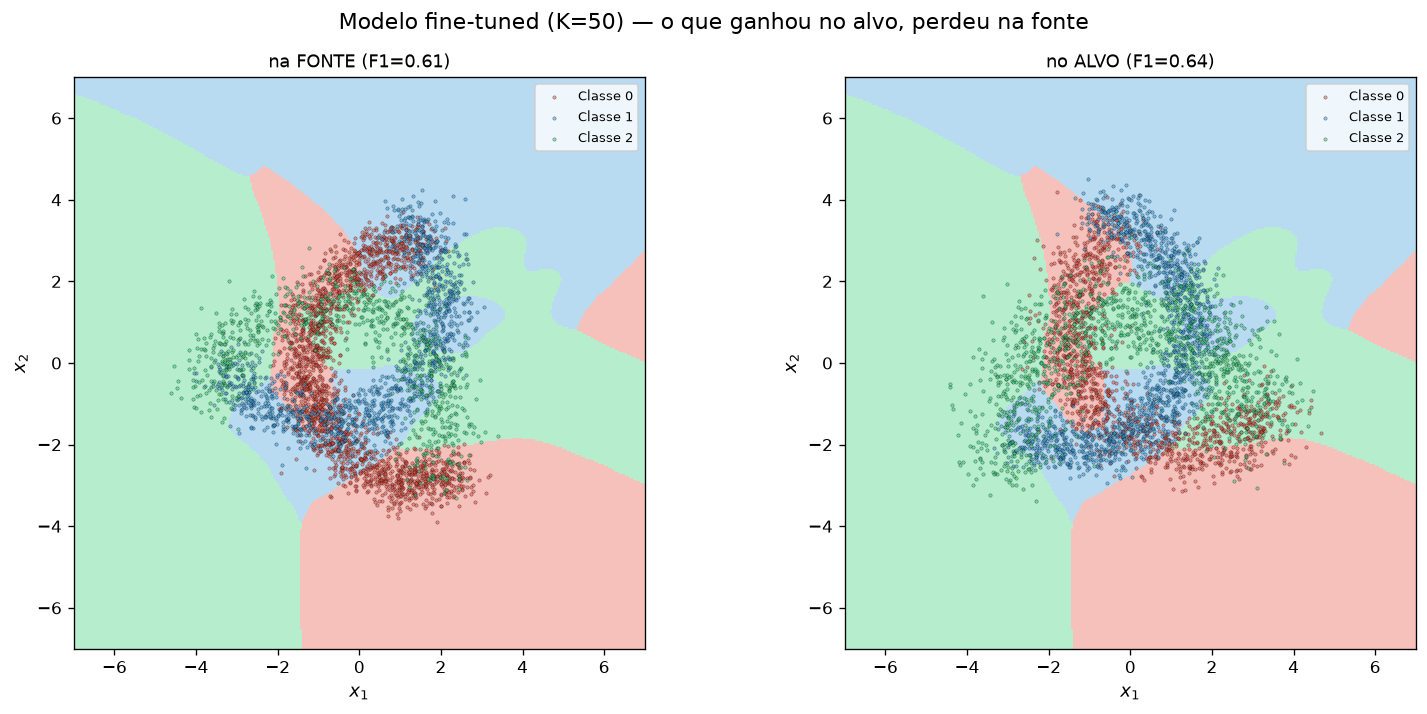

In [34]:
# Visualizar o esquecimento: fine-tuned total avaliado na FONTE vs. no ALVO
probs_ft_src = probabilidades_malha(modelo_ft, xx, yy)
probs_ft_tgt = probs_ft_src  # mesmo modelo, mudam só os pontos sobrepostos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(f"Modelo fine-tuned (K={K_DEMO}) — o que ganhou no alvo, perdeu na fonte",
             fontsize=13)
plotar_mapa_decisao(ax1, modelo_ft, X_val, y_val,
                    f"na FONTE (F1={linhas[1][2]:.2f})", xx, yy, probs=probs_ft_src)
ax1.legend(fontsize=8, loc="upper right")
plotar_mapa_decisao(ax2, modelo_ft, X_alvo_val, y_alvo_val,
                    f"no ALVO (F1={linhas[1][1]:.2f})", xx, yy, probs=probs_ft_tgt)
ax2.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

---
## Bloco 7 — Comparação final: pré-treino transfere estrutura

Voltamos ao $K$ pequeno (`K_DEMO`) e olhamos **lado a lado** as fronteiras dos
três regimes sobre o alvo. Esta é a versão *qualitativa* do argumento: o modelo
do zero, com poucos rótulos, fica **irregular / sobreajustado**; o fine-tuned
parece uma versão **sensatamente reorientada** das fronteiras da fonte.

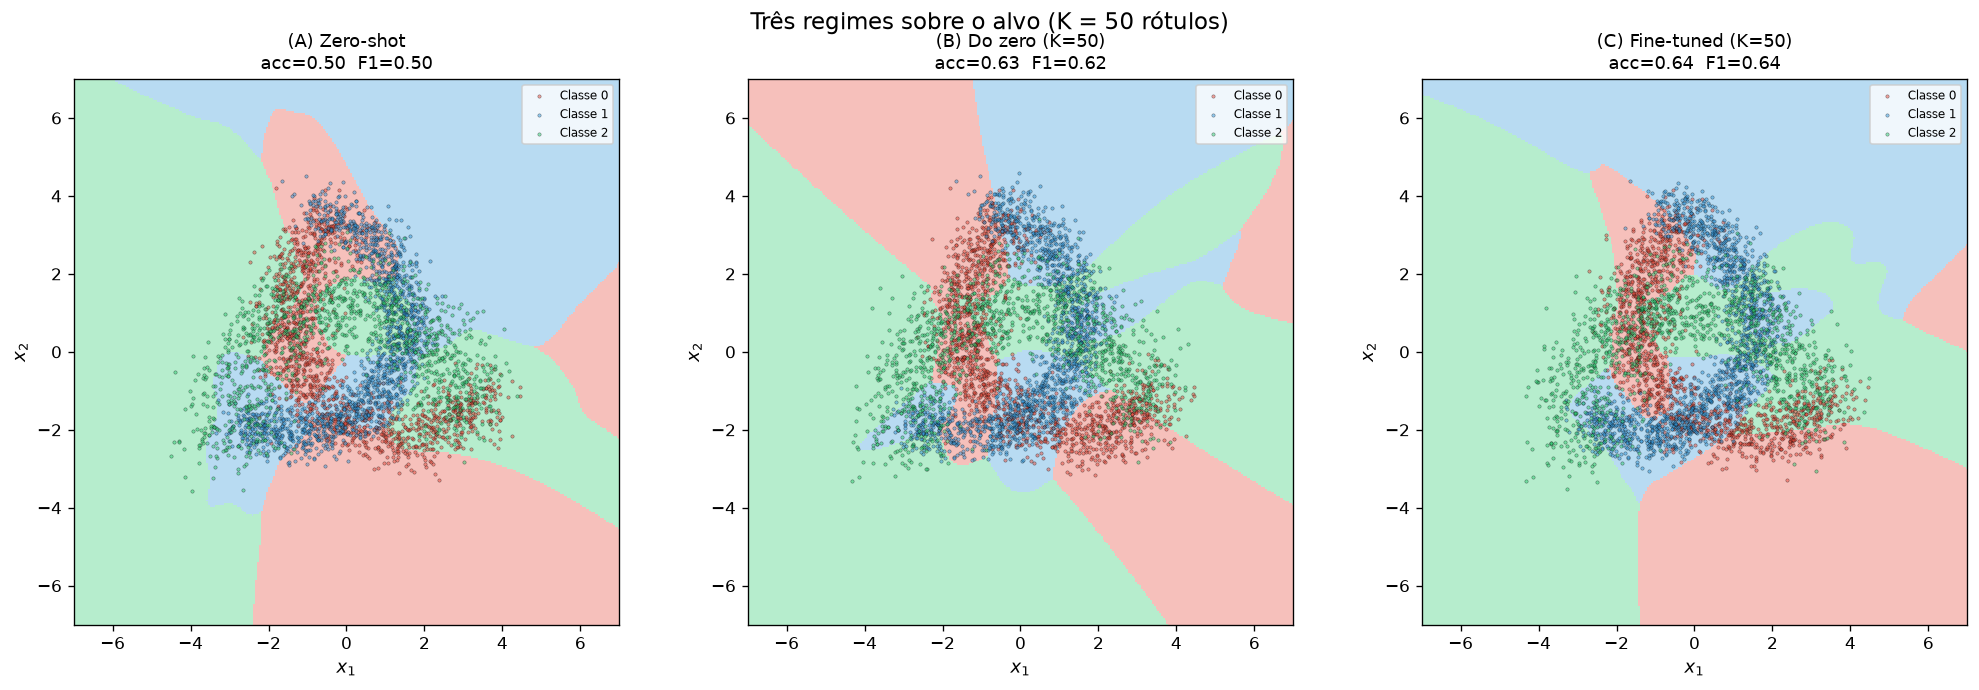

In [35]:
# Métricas dos modelos do K_DEMO
def metr(m):
    preds = np.array(jnp.argmax(jax.vmap(m)(X_alvo_val), axis=-1))
    return metricas_classificacao(np.array(y_alvo_val), preds)


cm_A, _, _, f1_A, acc_A = cm_alvo, None, None, f1_alvo, acc_alvo    # zero-shot
cm_B, _, _, f1_B, acc_B = metr(modelo_scratch)
cm_C, _, _, f1_C, acc_C = metr(modelo_ft)

probs_malha_scratch = probabilidades_malha(modelo_scratch, xx, yy)
probs_malha_ft = probabilidades_malha(modelo_ft, xx, yy)

fig, axes = plt.subplots(1, 3, figsize=(17, 5.6))
fig.suptitle(f"Três regimes sobre o alvo (K = {K_DEMO} rótulos)", fontsize=14)
plotar_mapa_decisao(axes[0], modelo, X_alvo_val, y_alvo_val,
                    f"(A) Zero-shot\nacc={acc_A:.2f}  F1={f1_A.mean():.2f}",
                    xx, yy, probs=probs_malha_fonte)
plotar_mapa_decisao(axes[1], modelo_scratch, X_alvo_val, y_alvo_val,
                    f"(B) Do zero (K={K_DEMO})\nacc={acc_B:.2f}  F1={f1_B.mean():.2f}",
                    xx, yy, probs=probs_malha_scratch)
plotar_mapa_decisao(axes[2], modelo_ft, X_alvo_val, y_alvo_val,
                    f"(C) Fine-tuned (K={K_DEMO})\nacc={acc_C:.2f}  F1={f1_C.mean():.2f}",
                    xx, yy, probs=probs_malha_ft)
for a in axes:
    a.legend(fontsize=7, loc="upper right")
plt.tight_layout()
plt.show()

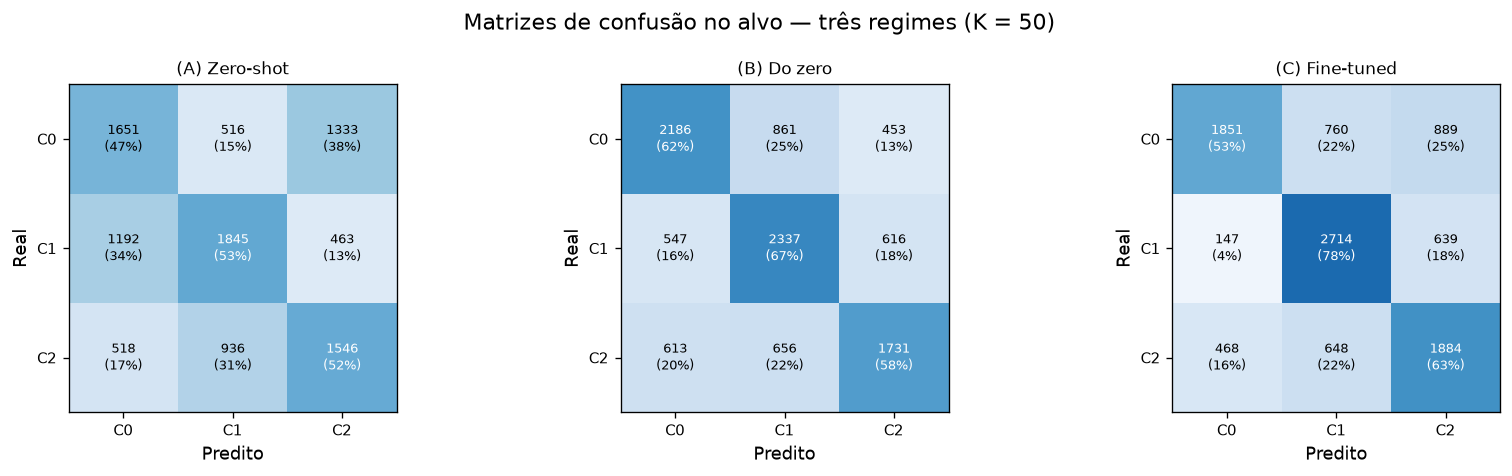

In [36]:
# Matrizes de confusão — três regimes
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f"Matrizes de confusão no alvo — três regimes (K = {K_DEMO})", fontsize=13)
plotar_matriz_confusao(ax1, cm_A, "(A) Zero-shot")
plotar_matriz_confusao(ax2, cm_B, "(B) Do zero")
plotar_matriz_confusao(ax3, cm_C, "(C) Fine-tuned")
plt.tight_layout()
plt.show()

In [37]:
# Tabela-resumo
print("=" * 58)
print(f"{'Regime':<26} {'acc alvo':>10} {'macro-F1 alvo':>15}")
print("=" * 58)
print(f"{'(A) Zero-shot (0 rótulos)':<26} {acc_A:>10.3f} {f1_A.mean():>15.3f}")
print(f"{'(B) Do zero (K=' + str(K_DEMO) + ')':<26} {acc_B:>10.3f} {f1_B.mean():>15.3f}")
print(f"{'(C) Fine-tuned (K=' + str(K_DEMO) + ')':<26} {acc_C:>10.3f} {f1_C.mean():>15.3f}")
print("-" * 58)
print(f"Teto (fonte na fonte):            macro-F1 = {F1_FONTE:.3f}")
print("=" * 58)

Regime                       acc alvo   macro-F1 alvo
(A) Zero-shot (0 rótulos)       0.504           0.504
(B) Do zero (K=50)              0.625           0.624
(C) Fine-tuned (K=50)           0.645           0.640
----------------------------------------------------------
Teto (fonte na fonte):            macro-F1 = 0.772


### Takeaway

> **Domain shift degrada em silêncio; fine-tuning conserta — e conserta com poucos rótulos.**

O que aprendemos:

1. Um modelo pode ter **alta confiança e estar errado** quando o domínio muda.
   Giramos o domínio e medimos a degradação de forma **controlada e monótona**.

2. **Métricas por classe** (TPR, F1, AUC) revelam degradações que a acurácia
   global esconde — especialmente na classe minoritária, mais afetada.

3. **Fine-tuning compra eficiência de rótulos:** com poucos $K$, partir de um
   modelo pré-treinado bate treinar do zero por larga margem; o do-zero só
   alcança com muitos rótulos. Pré-treino **transfere estrutura**.

4. Adaptar tem **custo**: o fine-tuning no alvo faz o modelo **esquecer** parte
   da fonte (esquecimento catastrófico). Adaptar só a última camada é mais
   barato e esquece menos — um trade-off de projeto (ligação com L2B1).

Na próxima aula (L3), veremos como o **aprendizado contrastivo** constrói
representações naturalmente mais robustas a mudanças de domínio.

---
## Para casa

**Exercício 1 — O ângulo de trabalho**

Refaça o Bloco 5 com `THETA_TRAB = 20°` e com `THETA_TRAB = 60°`. Como muda a
degradação zero-shot? Para qual ângulo o modelo fonte ainda é "aceitável" sem
adaptação?

**Exercício 2 — Onde está o joelho da curva?**

Na figura-chave (macro-F1 vs. $K$), a partir de qual $K$ o fine-tuning total
praticamente encosta no teto da fonte? E a partir de qual $K$ o do-zero
empata com o fine-tuned? Relacione com o custo de rotular no seu problema real.

**Exercício 3 — Learning rate do fine-tuning**

Aumente `LR_FT` para `3e-3` (igual ao do-zero) e refaça o sweep. O que acontece
com a vantagem do fine-tuned em $K$ pequeno? (Dica: um passo grande demais
"reinicia" o modelo e joga fora o pré-treino — a vantagem quase some.)